## Section 1 — Imports & Data Loading

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

SEED = 42
np.random.seed(SEED)

# --- Load raw splits ---
X_train_raw = pd.read_csv('data/processed/X_train.csv')
X_test_raw  = pd.read_csv('data/processed/X_test.csv')
y_train     = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test      = pd.read_csv('data/processed/y_test.csv').squeeze()
X_predict_raw = pd.read_csv('data/processed/X_predict.csv')

print(f'X_train_raw:   {X_train_raw.shape}')
print(f'X_test_raw:    {X_test_raw.shape}')
print(f'X_predict_raw: {X_predict_raw.shape}')
print(f'\nClass distribution (train):')
print(y_train.value_counts())

X_train_raw:   (460, 14)
X_test_raw:    (116, 14)
X_predict_raw: (567, 14)

Class distribution (train):
expected_profit_band
Medium    174
Low       145
High      141
Name: count, dtype: int64


## Section 2 — Feature Engineering

In [2]:
AGE_ORDER = {
    'Under 25': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55-64': 4,
    '65+': 5,
}

TIMELINE_URGENCY = {
    'Flexible': 0,
    '1 month': 1,
    '1-2 weeks': 2,
    'ASAP': 3,
}

HIGH_VALUE_PROPERTY = {'Detached', 'Semi-Detached', 'Heritage'}


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all feature engineering. Uses no target information (no leakage)."""
    df = df.copy()

    # Ordinal encoding for age bracket
    df['age_ordinal'] = df['customer_age_bracket'].map(AGE_ORDER).fillna(2).astype(int)

    # Urgency score from timeline
    df['timeline_urgency'] = df['requested_timeline'].map(TIMELINE_URGENCY).fillna(0).astype(int)

    # Job size tier (quartile bins computed from column values)
    sqft = df['estimated_job_size_sqft']
    q1, q2, q3 = sqft.quantile([0.25, 0.50, 0.75])
    def _size_tier(v):
        if v <= q1: return 'Small'
        if v <= q2: return 'Medium'
        if v <= q3: return 'Large'
        return 'XLarge'
    df['job_size_tier'] = sqft.apply(_size_tier)

    # Value density: sqft per km (larger job, closer distance = more profitable)
    df['sqft_per_km'] = df['estimated_job_size_sqft'] / (df['distance_to_queens_km'] + 0.1)

    # Binary flag: large job AND close distance
    df['is_large_and_close'] = (
        (df['estimated_job_size_sqft'] >= q2) &
        (df['distance_to_queens_km'] <= df['distance_to_queens_km'].median())
    ).astype(int)

    # Binary flag: homeowner + high-value property type
    df['is_homeowner_detached'] = (
        (df['homeowner_status'] == 'Own') &
        (df['property_type'].isin(HIGH_VALUE_PROPERTY))
    ).astype(int)

    return df


# Apply to all splits
X_train = engineer_features(X_train_raw)
X_test  = engineer_features(X_test_raw)
X_predict = engineer_features(X_predict_raw)

# Recombine for cross-validation (576 labeled rows)
X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([y_train, y_test], ignore_index=True)

# Categorical features (original + new categorical)
CAT_FEATURES = [
    'property_type',
    'neighbourhood',
    'requested_timeline',
    'referral_source',
    'homeowner_status',
    'preferred_contact',
    'lead_capture_weather',
    'customer_age_bracket',
    'lead_weekday',
    'job_size_tier',
]

print(f'X_train shape after engineering: {X_train.shape}')
print(f'X_full shape (train+test):       {X_full.shape}')
print(f'New features: age_ordinal, timeline_urgency, job_size_tier, sqft_per_km, is_large_and_close, is_homeowner_detached')
print(f'Total features: {X_train.shape[1]}')

X_train shape after engineering: (460, 20)
X_full shape (train+test):       (576, 20)
New features: age_ordinal, timeline_urgency, job_size_tier, sqft_per_km, is_large_and_close, is_homeowner_detached
Total features: 20


## Section 3 — Cross-Validation Infrastructure

In [3]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def evaluate_cv(params: dict, X: pd.DataFrame, y: pd.Series, cat_features: list) -> dict:
    """5-fold stratified CV. Returns mean accuracy, macro F1, and per-class F1."""
    acc_scores, f1_scores = [], []
    per_class_f1 = {cls: [] for cls in ['Low', 'Medium', 'High']}

    for fold, (tr_idx, va_idx) in enumerate(CV.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        m = CatBoostClassifier(
            **params,
            loss_function='MultiClass',
            eval_metric='TotalF1:average=Macro',
            random_seed=SEED,
            verbose=0,
        )
        m.fit(
            X_tr, y_tr,
            cat_features=cat_features,
            eval_set=(X_va, y_va),
            early_stopping_rounds=50,
        )
        y_pred = m.predict(X_va).flatten()

        acc_scores.append(accuracy_score(y_va, y_pred))
        f1_scores.append(f1_score(y_va, y_pred, average='macro', labels=['Low', 'Medium', 'High']))

        report = classification_report(y_va, y_pred, labels=['Low', 'Medium', 'High'],
                                       output_dict=True, zero_division=0)
        for cls in per_class_f1:
            per_class_f1[cls].append(report.get(cls, {}).get('f1-score', 0.0))

    return {
        'acc_mean':    np.mean(acc_scores),
        'acc_std':     np.std(acc_scores),
        'f1_mean':     np.mean(f1_scores),
        'f1_std':      np.std(f1_scores),
        'per_class_f1': {cls: (np.mean(v), np.std(v)) for cls, v in per_class_f1.items()},
    }


# Baseline CV with original default params (no tuning)
baseline_params = {
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'early_stopping_rounds': 50,
}
print('Running baseline 5-fold CV...')
baseline_cv = evaluate_cv(baseline_params, X_full, y_full, CAT_FEATURES)
print(f"Baseline CV  ->  Accuracy: {baseline_cv['acc_mean']:.4f} ± {baseline_cv['acc_std']:.4f}   "
      f"Macro F1: {baseline_cv['f1_mean']:.4f} ± {baseline_cv['f1_std']:.4f}")
for cls, (mu, sd) in baseline_cv['per_class_f1'].items():
    print(f'  {cls:6s} F1: {mu:.4f} ± {sd:.4f}')

Running baseline 5-fold CV...


Baseline CV  ->  Accuracy: 0.7483 ± 0.0261   Macro F1: 0.7534 ± 0.0269
  Low    F1: 0.7654 ± 0.0763
  Medium F1: 0.6953 ± 0.0283
  High   F1: 0.7996 ± 0.0611


## Section 4 — Hyperparameter Optimization (Optuna, 200 trials)

In [4]:
def objective(trial):
    params = {
        'iterations':          2000,
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':               trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength':     trial.suggest_float('random_strength', 0.5, 5.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 3.0),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        'one_hot_max_size':    trial.suggest_int('one_hot_max_size', 2, 10),
        'grow_policy':         trial.suggest_categorical('grow_policy',
                                   ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'auto_class_weights':  trial.suggest_categorical('auto_class_weights',
                                   ['None', 'Balanced', 'SqrtBalanced']),
        'early_stopping_rounds': 50,
    }
    # CatBoost expects None, not the string 'None'
    if params['auto_class_weights'] == 'None':
        params['auto_class_weights'] = None

    result = evaluate_cv(params, X_full, y_full, CAT_FEATURES)
    return result['f1_mean']


study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
print('Running Optuna (200 trials × 5-fold CV). This will take ~10-15 minutes...')
study.optimize(objective, n_trials=200, show_progress_bar=True)

best_params = study.best_params.copy()
best_params['iterations'] = 2000
best_params['early_stopping_rounds'] = 50
if best_params.get('auto_class_weights') == 'None':
    best_params['auto_class_weights'] = None

print(f'\nBest Macro F1 (CV): {study.best_value:.4f}')
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Running Optuna (200 trials × 5-fold CV). This will take ~10-15 minutes...


  0%|          | 0/200 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.747736:   0%|          | 0/200 [00:01<?, ?it/s]

Best trial: 0. Best value: 0.747736:   0%|          | 1/200 [00:01<05:04,  1.53s/it]

Best trial: 1. Best value: 0.752689:   0%|          | 1/200 [00:01<05:04,  1.53s/it]

...

Best trial: 144. Best value: 0.778672: 100%|█████████▉| 199/200 [02:31<00:00,  2.64it/s]

Best trial: 144. Best value: 0.778672: 100%|█████████▉| 199/200 [02:32<00:00,  2.64it/s]

Best trial: 144. Best value: 0.778672: 100%|██████████| 200/200 [02:32<00:00,  2.69it/s]

Best trial: 144. Best value: 0.778672: 100%|██████████| 200/200 [02:32<00:00,  1.31it/s]


Best Macro F1 (CV): 0.7787
Best hyperparameters:
  learning_rate: 0.1257934499324771
  depth: 4
  l2_leaf_reg: 4.2308261222393595
  random_strength: 3.0849453613732436
  bagging_temperature: 0.7713405860560613
  border_count: 63
  one_hot_max_size: 5
  grow_policy: Depthwise
  auto_class_weights: Balanced
  iterations: 2000
  early_stopping_rounds: 50


## Section 5 — Optuna Results Analysis

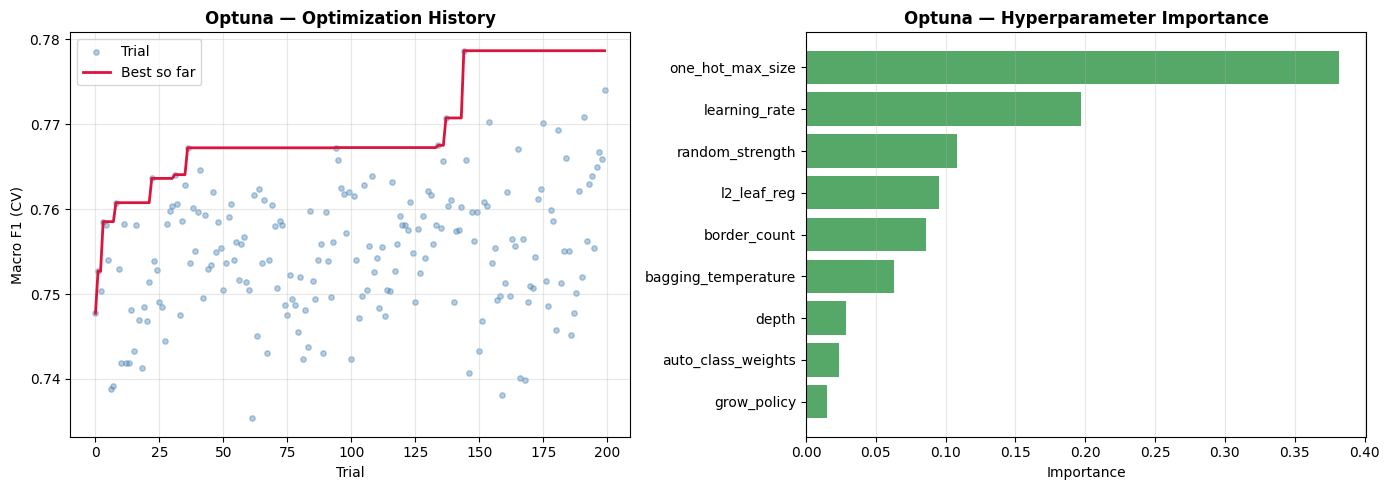

Top-5 Optuna trials:
 trial  macro_f1  learning_rate  depth  l2_leaf_reg  random_strength  bagging_temperature  border_count  one_hot_max_size grow_policy auto_class_weights
   144    0.7787         0.1258      4       4.2308           3.0849               0.7713            63                 5   Depthwise           Balanced
   199    0.7741         0.1901      4       6.0373           2.5658               1.2859            50                 5   Depthwise           Balanced
   191    0.7709         0.1347      4       6.0369           2.9462               1.1536            52                 5   Depthwise           Balanced
   137    0.7707         0.0945      4       3.9103           3.2763               0.7963            54                 5   Depthwise           Balanced
   154    0.7703         0.1086      4       6.6926           3.1015               0.9994            52                 5   Depthwise           Balanced


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trial_nums  = [t.number for t in study.trials if t.value is not None]
trial_vals  = [t.value  for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(trial_vals)

axes[0].scatter(trial_nums, trial_vals, alpha=0.4, s=15, color='steelblue', label='Trial')
axes[0].plot(trial_nums, best_so_far, color='crimson', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Macro F1 (CV)')
axes[0].set_title('Optuna — Optimization History', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Parameter importance (Optuna built-in)
importances = optuna.importance.get_param_importances(study)
param_names = list(importances.keys())
param_vals  = list(importances.values())
sorted_idx  = np.argsort(param_vals)
axes[1].barh([param_names[i] for i in sorted_idx],
             [param_vals[i]  for i in sorted_idx],
             color='#55A868')
axes[1].set_xlabel('Importance')
axes[1].set_title('Optuna — Hyperparameter Importance', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
fig.savefig('figures/08b_catboost_optuna_history.png', dpi=150)
plt.show()

# Top-5 trials table
top5 = sorted(study.trials, key=lambda t: t.value or 0, reverse=True)[:5]
rows = []
for t in top5:
    row = {'trial': t.number, 'macro_f1': round(t.value, 4)}
    row.update({k: round(v, 4) if isinstance(v, float) else v
                for k, v in t.params.items()})
    rows.append(row)
print('Top-5 Optuna trials:')
print(pd.DataFrame(rows).to_string(index=False))

## Section 6 — Train Final Models

In [6]:
# --- Evaluation model: train on X_train, evaluate on X_test (apples-to-apples comparison) ---
eval_params = best_params.copy()

eval_model = CatBoostClassifier(
    **eval_params,
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    random_seed=SEED,
    verbose=100,
)
eval_model.fit(
    X_train, y_train,
    cat_features=CAT_FEATURES,
    eval_set=(X_test, y_test),
)
best_iteration = eval_model.best_iteration_
print(f'\nEvaluation model best iteration: {best_iteration}')

# --- Production model: trained on ALL 576 labeled rows, fixed iteration count ---
prod_params = best_params.copy()
prod_params['iterations'] = best_iteration or 500
prod_params.pop('early_stopping_rounds', None)  # no early stop needed

prod_model = CatBoostClassifier(
    **prod_params,
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    random_seed=SEED,
    verbose=100,
)
prod_model.fit(X_full, y_full, cat_features=CAT_FEATURES)
print(f'\nProduction model trained on {len(X_full)} rows.')

0:	learn: 0.5630781	test: 0.5493953	best: 0.5493953 (0)	total: 846us	remaining: 1.69s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.754954291
bestIteration = 13

Shrink model to first 14 iterations.

Evaluation model best iteration: 13
0:	learn: 0.6964581	total: 767us	remaining: 9.21ms
12:	learn: 0.7679157	total: 10.1ms	remaining: 0us

Production model trained on 576 rows.


## Section 7 — Test Set Evaluation (vs Baseline)

In [7]:
y_pred = eval_model.predict(X_test).flatten()

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', labels=['Low', 'Medium', 'High'])

BASELINE_ACC = 0.75

print('=' * 55)
print(f'  Baseline accuracy:  {BASELINE_ACC:.4f}  ({BASELINE_ACC*100:.1f}%)')
print(f'  Tuned accuracy:     {acc:.4f}  ({acc*100:.1f}%)   '
      f"({'▲' if acc > BASELINE_ACC else '▼'} {abs(acc - BASELINE_ACC)*100:.1f} pp)")
print(f'  Tuned macro F1:     {macro_f1:.4f}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred,
                             labels=['Low', 'Medium', 'High'],
                             target_names=['Low', 'Medium', 'High']))

# Medium class deep-dive
medium_mask = (y_test == 'Medium')
medium_preds = y_pred[medium_mask]
print('Medium class breakdown:')
for lbl, cnt in pd.Series(medium_preds).value_counts().items():
    status = '✓ correct' if lbl == 'Medium' else '✗ wrong'
    print(f'  Predicted {lbl:6s}: {cnt:3d}  {status}')

  Baseline accuracy:  0.7500  (75.0%)
  Tuned accuracy:     0.7500  (75.0%)   (▼ 0.0 pp)
  Tuned macro F1:     0.7524

              precision    recall  f1-score   support

         Low       0.74      0.94      0.83        36
      Medium       0.68      0.64      0.66        44
        High       0.86      0.69      0.77        36

    accuracy                           0.75       116
   macro avg       0.76      0.76      0.75       116
weighted avg       0.76      0.75      0.75       116

Medium class breakdown:
  Predicted Medium:  28  ✓ correct
  Predicted Low   :  12  ✗ wrong
  Predicted High  :   4  ✗ wrong


## Section 8 — Cross-Validated Metrics (Most Trustworthy Estimate)

In [8]:
print('Running final 5-fold CV with tuned hyperparameters on all 576 labeled rows...')
tuned_cv = evaluate_cv(best_params, X_full, y_full, CAT_FEATURES)

print('\n── Cross-Validated Metrics (5-fold, Stratified) ────────────────')
print(f"  Accuracy:  {tuned_cv['acc_mean']:.4f} ± {tuned_cv['acc_std']:.4f}")
print(f"  Macro F1:  {tuned_cv['f1_mean']:.4f} ± {tuned_cv['f1_std']:.4f}")
print()
print('  Per-class F1 (mean ± std):')
for cls, (mu, sd) in tuned_cv['per_class_f1'].items():
    delta = ''
    baseline_f1 = {'Low': 0.82, 'Medium': 0.70, 'High': 0.73}  # approximate baseline
    direction = '▲' if mu > baseline_f1.get(cls, 0) else '▼'
    print(f'    {cls:6s}: {mu:.4f} ± {sd:.4f}  {direction}')

print()
print(f"  Baseline CV Accuracy: {baseline_cv['acc_mean']:.4f} ± {baseline_cv['acc_std']:.4f}")
print(f"  Baseline CV Macro F1: {baseline_cv['f1_mean']:.4f} ± {baseline_cv['f1_std']:.4f}")

Running final 5-fold CV with tuned hyperparameters on all 576 labeled rows...



── Cross-Validated Metrics (5-fold, Stratified) ────────────────
  Accuracy:  0.7743 ± 0.0161
  Macro F1:  0.7787 ± 0.0158

  Per-class F1 (mean ± std):
    Low   : 0.8264 ± 0.0350  ▲
    Medium: 0.7073 ± 0.0252  ▲
    High  : 0.8023 ± 0.0652  ▲

  Baseline CV Accuracy: 0.7483 ± 0.0261
  Baseline CV Macro F1: 0.7534 ± 0.0269


## Section 9 — Confusion Matrix

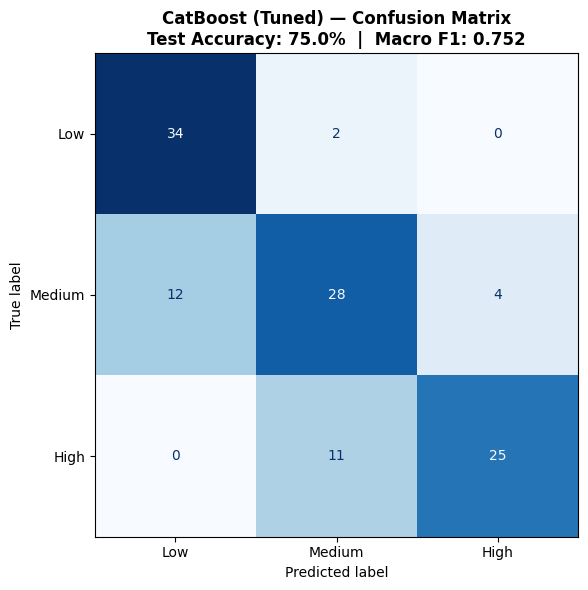

In [9]:
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(
    f'CatBoost (Tuned) — Confusion Matrix\nTest Accuracy: {acc*100:.1f}%  |  Macro F1: {macro_f1:.3f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig('figures/08_catboost_confusion_matrix.png', dpi=150)
plt.show()

## Section 10 — Feature Importance & SHAP

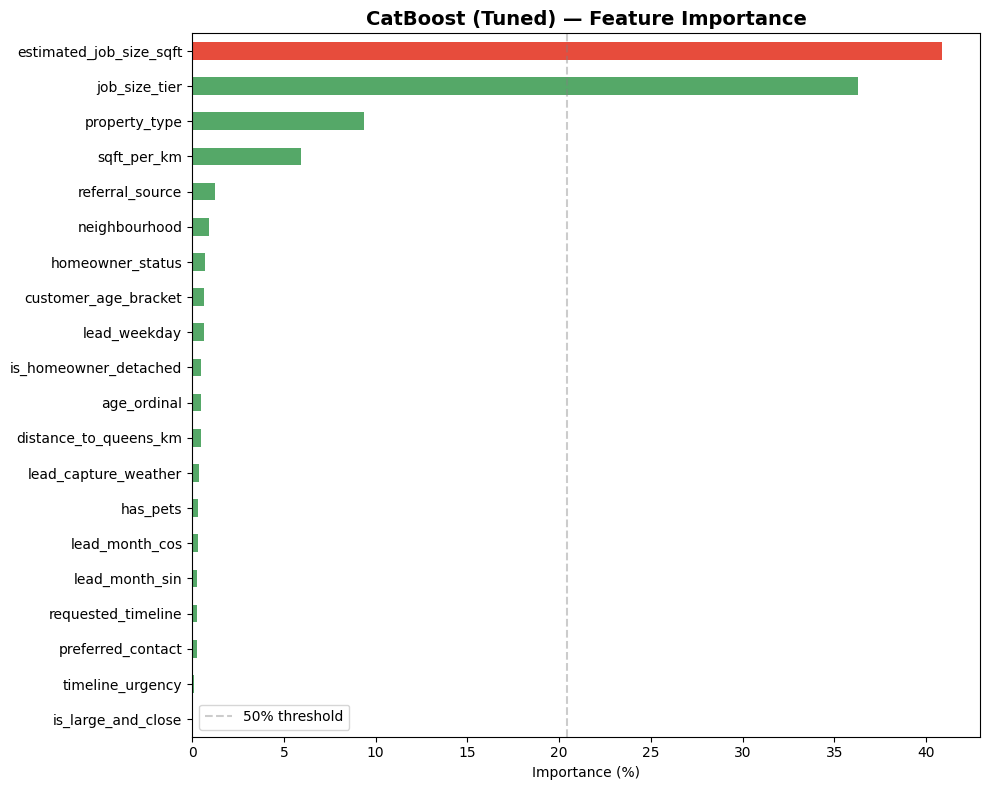

Feature importances (descending):
  estimated_job_size_sqft         40.9%  ████████████████████
  job_size_tier                   36.3%  ██████████████████
  property_type                    9.4%  ████
  sqft_per_km                      5.9%  ██
  referral_source                  1.3%  
  neighbourhood                    0.9%  
  homeowner_status                 0.7%  
  customer_age_bracket             0.7%  
  lead_weekday                     0.6%  
  is_homeowner_detached            0.5%  
  age_ordinal                      0.5%  
  distance_to_queens_km            0.5%  
  lead_capture_weather             0.4%  
  has_pets                         0.3%  
  lead_month_cos                   0.3%  
  lead_month_sin                   0.3%  
  requested_timeline               0.3%  
  preferred_contact                0.2%  
  timeline_urgency                 0.1%  
  is_large_and_close               0.0%  


In [10]:
# Native CatBoost feature importance
importances = eval_model.get_feature_importance()
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E74C3C' if feat_imp.index[-1] == name else '#55A868' for name in feat_imp.index]
feat_imp.plot.barh(ax=ax, color=colors)
ax.set_title('CatBoost (Tuned) — Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (%)')
ax.axvline(x=feat_imp.max() * 0.5, linestyle='--', alpha=0.4, color='gray', label='50% threshold')
ax.legend()
plt.tight_layout()
fig.savefig('figures/09_catboost_feature_importance.png', dpi=150)
plt.show()

print('Feature importances (descending):')
for name, imp in feat_imp.sort_values(ascending=False).items():
    bar = '█' * int(imp / 2)
    print(f'  {name:30s} {imp:5.1f}%  {bar}')

Saved figures/09b_catboost_shap.png


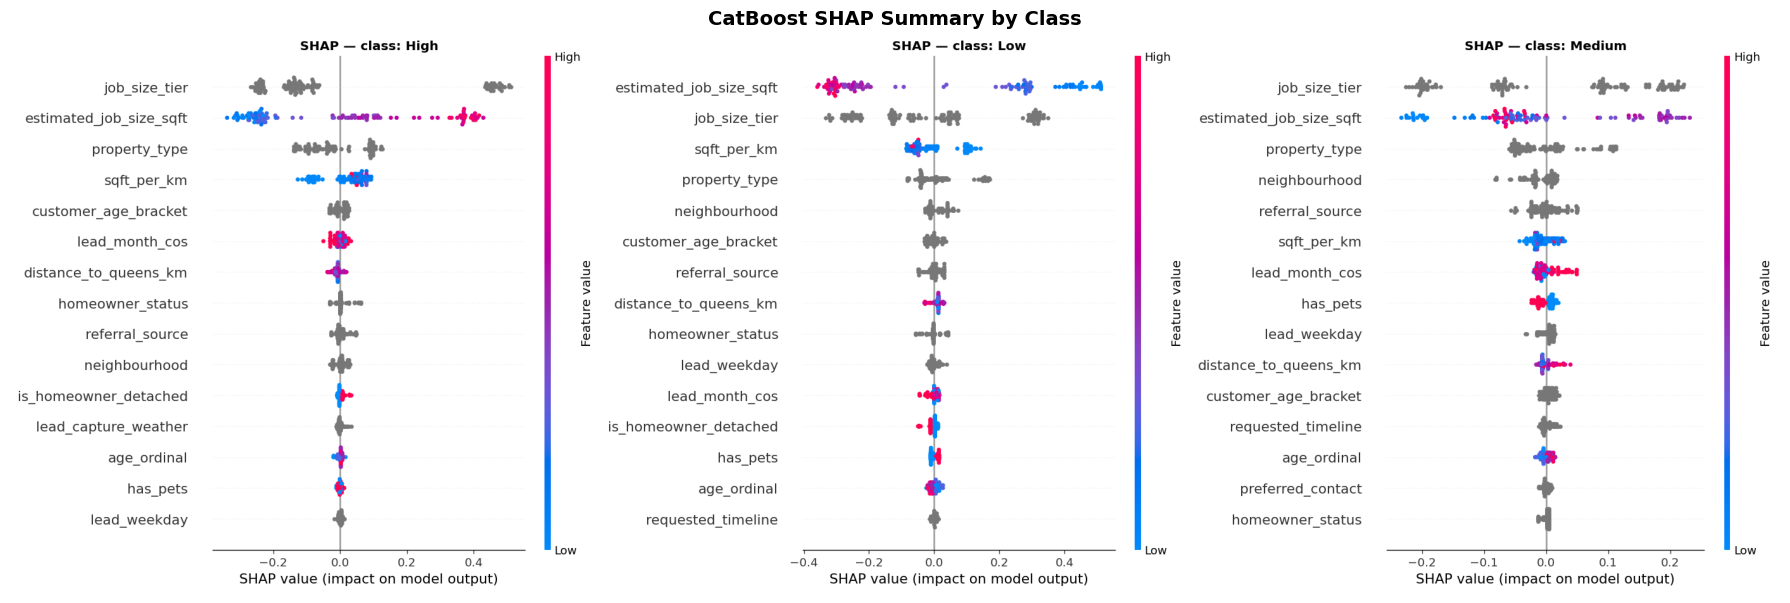

In [11]:
# SHAP analysis using CatBoost's native ShapValues (correct handling of cat features)
import io
from PIL import Image

# CatBoost computes SHAP in its native feature space (no shape mismatch)
# Returns shape (n_samples, n_features+1, n_classes) — last col is bias
shap_raw = eval_model.get_feature_importance(
    data=Pool(X_test, cat_features=CAT_FEATURES),
    type='ShapValues',
)
# shap_raw shape: (n_samples, n_classes, n_features+1)  OR  (n_samples, n_features+1, n_classes)
# Normalize to list of [n_samples, n_features] arrays, one per class
import shap as shap_lib

classes = eval_model.classes_
feature_names = list(X_train.columns)

# Determine layout: CatBoost returns (n_samples, n_features+1) for binary
# and (n_samples, n_classes, n_features+1) for multiclass
if shap_raw.ndim == 3:
    # Multiclass: axis order is (n_samples, n_classes, n_features+1)
    shap_per_class = [shap_raw[:, c, :-1] for c in range(len(classes))]
else:
    # Binary / fallback
    shap_per_class = [shap_raw[:, :-1]]

class_images = []
for i, cls in enumerate(classes):
    sv = shap_per_class[i]   # (n_samples, n_features)
    plt.figure(figsize=(7, 7))
    shap_lib.summary_plot(
        sv,
        X_test[feature_names].values,
        feature_names=feature_names,
        show=False,
        max_display=15,
    )
    plt.title(f'SHAP — class: {cls}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
    buf.seek(0)
    class_images.append(Image.open(buf).copy())
    plt.close()

# Stitch side-by-side
total_w = sum(img.width for img in class_images)
max_h   = max(img.height for img in class_images)
combined = Image.new('RGB', (total_w, max_h), color='white')
x_offset = 0
for img in class_images:
    combined.paste(img, (x_offset, 0))
    x_offset += img.width
combined.save('figures/09b_catboost_shap.png', dpi=(150, 150))
print('Saved figures/09b_catboost_shap.png')

fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(np.array(combined))
ax.axis('off')
ax.set_title('CatBoost SHAP Summary by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 11 — Learning Curves & Overfitting Diagnostics

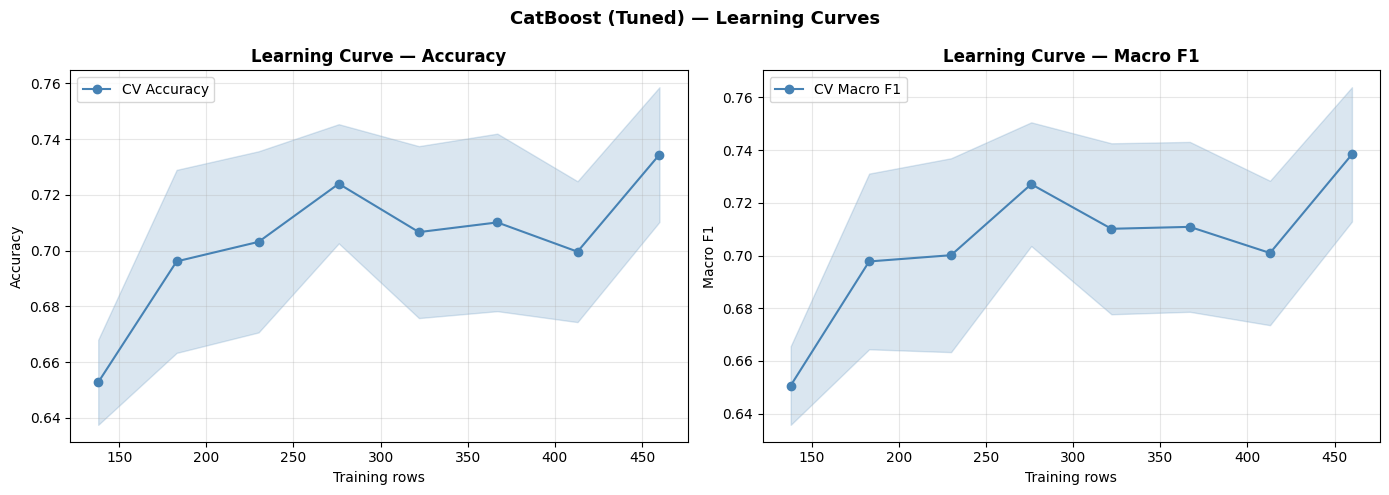

Saved figures/09c_catboost_learning_curves.png


In [12]:
# Learning curves: train size vs CV score
train_sizes = np.linspace(0.3, 1.0, 8)
lc_acc_means, lc_acc_stds = [], []
lc_f1_means,  lc_f1_stds  = [], []

lc_params = best_params.copy()
lc_params['iterations'] = best_iteration or 500
lc_params.pop('early_stopping_rounds', None)

for frac in train_sizes:
    acc_fold, f1_fold = [], []
    for tr_idx, va_idx in CV.split(X_full, y_full):
        n_sub = max(int(len(tr_idx) * frac), 10)
        sub_idx = tr_idx[:n_sub]
        X_tr, X_va = X_full.iloc[sub_idx], X_full.iloc[va_idx]
        y_tr, y_va = y_full.iloc[sub_idx], y_full.iloc[va_idx]

        m = CatBoostClassifier(**lc_params, loss_function='MultiClass',
                                random_seed=SEED, verbose=0)
        m.fit(X_tr, y_tr, cat_features=CAT_FEATURES)
        y_p = m.predict(X_va).flatten()
        acc_fold.append(accuracy_score(y_va, y_p))
        f1_fold.append(f1_score(y_va, y_p, average='macro', labels=['Low', 'Medium', 'High']))

    lc_acc_means.append(np.mean(acc_fold))
    lc_acc_stds.append(np.std(acc_fold))
    lc_f1_means.append(np.mean(f1_fold))
    lc_f1_stds.append(np.std(f1_fold))

n_rows = (X_full.shape[0] * 4 // 5 * train_sizes).astype(int)  # approx train rows per fold

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, means, stds, metric in zip(
    axes,
    [lc_acc_means, lc_f1_means],
    [lc_acc_stds,  lc_f1_stds],
    ['Accuracy', 'Macro F1']
):
    means, stds = np.array(means), np.array(stds)
    ax.plot(n_rows, means, 'o-', color='steelblue', label=f'CV {metric}')
    ax.fill_between(n_rows, means - stds, means + stds, alpha=0.2, color='steelblue')
    ax.set_xlabel('Training rows')
    ax.set_ylabel(metric)
    ax.set_title(f'Learning Curve — {metric}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('CatBoost (Tuned) — Learning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig('figures/09c_catboost_learning_curves.png', dpi=150)
plt.show()
print('Saved figures/09c_catboost_learning_curves.png')

## Section 12 — Production Artifacts & Predictions

In [13]:
import os
os.makedirs('models', exist_ok=True)

# Save production model
prod_model.save_model('models/catboost_lead_profitability.cbm')
print('Saved models/catboost_lead_profitability.cbm')

# Save metadata
metadata = {
    'model_type': 'CatBoostClassifier',
    'trained_on_rows': int(len(X_full)),
    'best_iteration': int(best_iteration or prod_params['iterations']),
    'best_params': {
        k: (str(v) if v is None else v)
        for k, v in best_params.items()
    },
    'cv_metrics': {
        'accuracy_mean': round(tuned_cv['acc_mean'], 4),
        'accuracy_std':  round(tuned_cv['acc_std'],  4),
        'macro_f1_mean': round(tuned_cv['f1_mean'],  4),
        'macro_f1_std':  round(tuned_cv['f1_std'],   4),
        'per_class_f1': {
            cls: {'mean': round(mu, 4), 'std': round(sd, 4)}
            for cls, (mu, sd) in tuned_cv['per_class_f1'].items()
        },
    },
    'test_metrics': {
        'accuracy':  round(float(acc), 4),
        'macro_f1':  round(float(macro_f1), 4),
    },
    'features': list(X_train.columns),
    'cat_features': CAT_FEATURES,
    'class_labels': list(prod_model.classes_),
    'optuna_best_f1': round(study.best_value, 4),
    'optuna_trials': len(study.trials),
}
with open('models/catboost_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved models/catboost_metadata.json')

# Generate predictions on unlabeled leads with confidence scoring
proba = prod_model.predict_proba(X_predict)
preds = prod_model.predict(X_predict).flatten()

results = X_predict_raw.copy()  # use raw (un-engineered) for readability
results['predicted_profit_band'] = preds

for i, cls in enumerate(prod_model.classes_):
    results[f'prob_{cls}'] = proba[:, i]

results['max_confidence'] = proba.max(axis=1)
results['is_confident']   = results['max_confidence'] >= 0.5

results.to_csv('catboost_predictions.csv', index=False)
print(f'\nSaved catboost_predictions.csv ({len(results)} rows)')

print('\nPredicted profit band distribution:')
print(results['predicted_profit_band'].value_counts())

print(f"\nConfidence summary:")
print(f"  High confidence (>=0.50): {results['is_confident'].sum()} / {len(results)}")
print(f"  Mean confidence:          {results['max_confidence'].mean():.3f}")
print(f"  Min confidence:           {results['max_confidence'].min():.3f}")

uncertain = results[~results['is_confident']]
if len(uncertain):
    print(f"\n  {len(uncertain)} leads flagged for manual review (confidence < 0.50)")

Saved models/catboost_lead_profitability.cbm


Saved models/catboost_metadata.json



Saved catboost_predictions.csv (567 rows)

Predicted profit band distribution:
predicted_profit_band
Medium    218
Low       184
High      165
Name: count, dtype: int64

Confidence summary:
  High confidence (>=0.50): 317 / 567
  Mean confidence:          0.551
  Min confidence:           0.379

  250 leads flagged for manual review (confidence < 0.50)
